In [1]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Introduction

Customer A is experiencing breakdowns on a machine which is causing delays in production. In recent times this has happened 1600 times and we have access to the sensor states at those times.

Engineers from customer A have been able to categorise 40 of these breakdowns into 3 main categories.

The goal of this project is to use the small section of labelled data to extrapolate to unlablled breakdowns. This has two functions:
1. The manual labelling can be time-intensive so this would save the customer time into analysis which category is most prevalent and needs most urgent attention.
2. The model that we obtain can be used to predict breakdown reason in real-time that saves trouble-shooting and reduces the time to resolve and resume production.
3. Insights from the model can be used to prevent further model breakdown.

This can be solved using a semi-supervised machine learning methods. 

This analysis will dig into the data and aim to guide a solution.

# Features

The 20 sensor features seem normalised from -1, 1.  

In [ ]:
data_path = "../data/input/data_sensors.csv"
data = pd.read_csv(data_path)
data.head()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,0.367026,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.144257,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,-0.675210,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.373325,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,-0.176694,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN


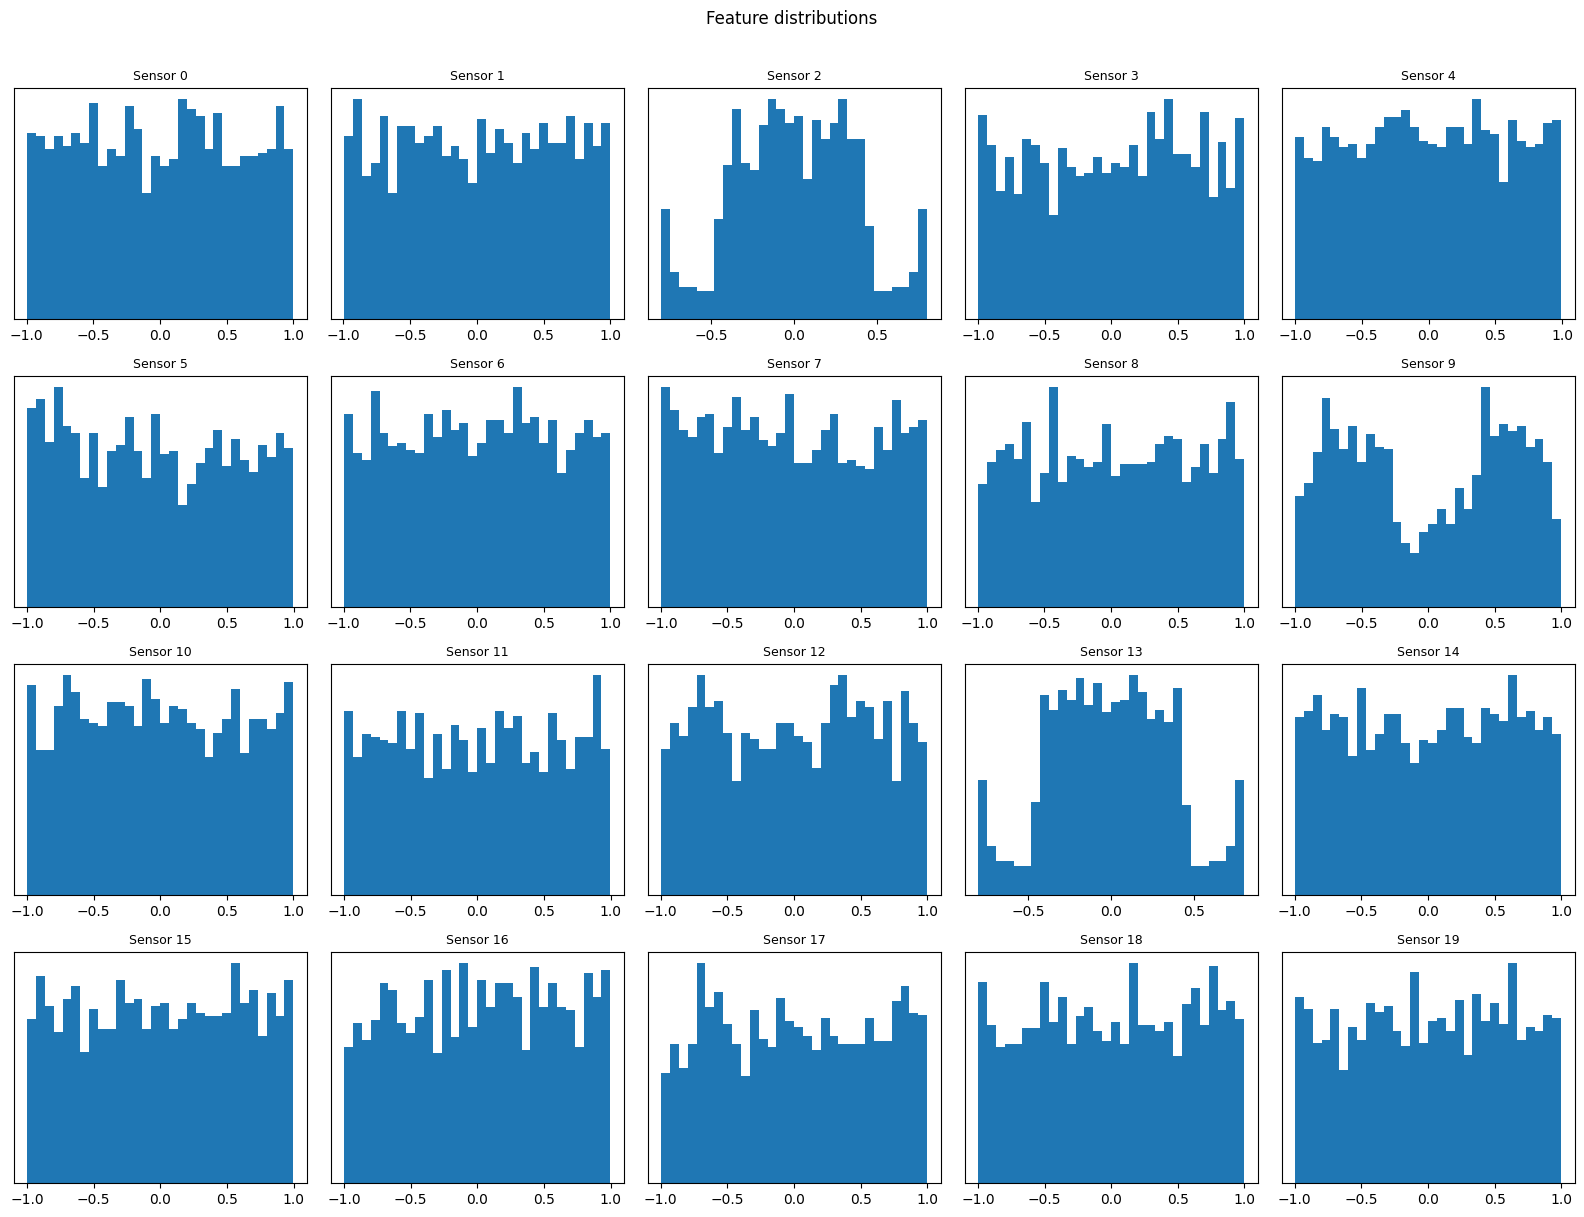

In [4]:
feature_cols = [c for c in data.columns if c != "Label"]

fig, axes = plt.subplots(4, 5, figsize=(16, 12))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(data[col], bins=30, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
plt.suptitle('Feature distributions', y=1.01)
plt.tight_layout()

# Label distribution

We have 3 labels and a 50/25/25% class imbalance

In [5]:
labeled = data[~data["Label"].isnull()]

<Axes: xlabel='Label', ylabel='count'>

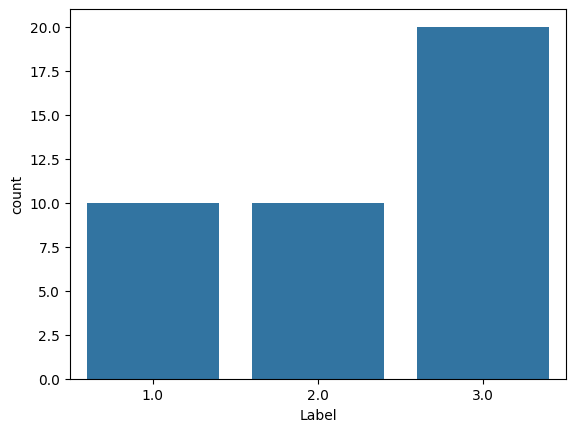

In [6]:
labels_known = data["Label"]
labels_known.value_counts()

sns.barplot(labels_known.value_counts())

# Cluster Visualisation

We try to plot the instances in a 2/3 dimensionsal space using a common dimensionality reduction technique. Using principle components analysis (PCA) we try to decompose the sensor data into a lower dimernsion find the dimensions that maximise the variance.

Reducing the dimensions allows us to plot the data of 20 sensors and lets us visually inspect if we notice any distinct patterns. If there is a clear visual separation of the clusters, this helps us formulate a clustering strategy.

Explained variance: 18.6%


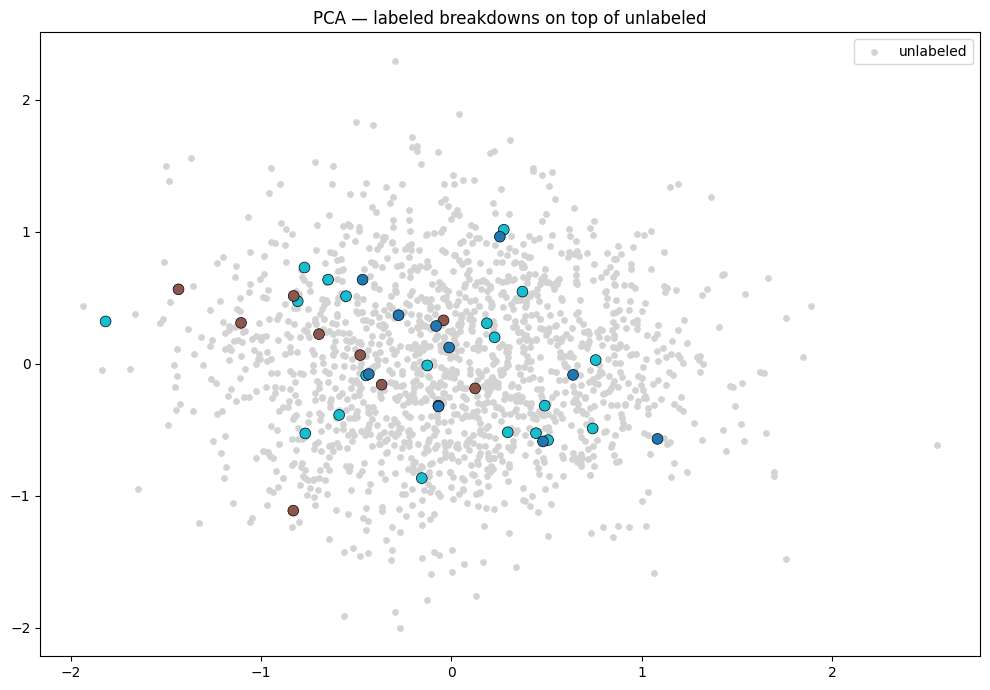

In [22]:
from sklearn.decomposition import PCA
import plotly.express as px

X = data[feature_cols].values


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 7))
# Unlabeled in grey
ax.scatter(X_pca[labels_known.isna(), 0], X_pca[labels_known.isna(), 1],
            c="lightgrey", s=15, label="unlabeled", zorder=1)

# Labeled colored by class
labeled_mask = labels_known.notna()
scatter = ax.scatter(X_pca[labeled_mask, 0], X_pca[labeled_mask, 1],
                    c=labels_known[labeled_mask].astype("category").cat.codes,
                    cmap="tab10", s=60, zorder=2, edgecolors="black", linewidths=0.5)
ax.legend()
plt.title("PCA — labeled breakdowns on top of unlabeled")
plt.tight_layout()

plt.show()

plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
plot_df["label"] = labels_known.fillna("unlabeled").astype(str)

fig3d = px.scatter_3d(
    plot_df, x="PC1", y="PC2", z="PC3",
    color="label",
    color_discrete_map={"unlabeled": "lightgrey"},
    opacity=0.7,
    title="PCA 3D — labeled breakdowns on top of unlabeled"
)
fig3d.update_traces(marker_size=4)
fig3d.show()

Unfortunately, the first 3 dimensions of this decomposition do not gives us a clear indication that there is a meaningful pattern visually. 

This is confirmed by the explained variance of the PCA. Every aded component adds about 6% of explained variance, meaning that the variance is almost spread evenly in every direction. 

If there was a clear structure to be uncovered, we would see that the initial components would explain a lot of the variance already, with diminishing returns.

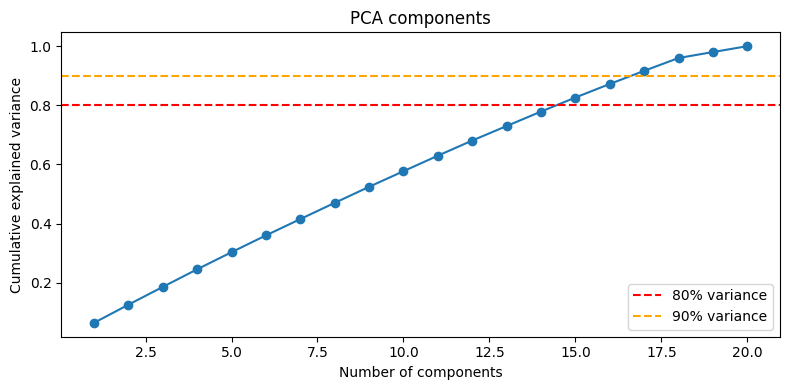

In [8]:
pca_full = PCA().fit(X)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o')
ax.axhline(0.8, color='red', linestyle='--', label='80% variance')
ax.axhline(0.9, color='orange', linestyle='--', label='90% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA components')
ax.legend()
plt.tight_layout()

## Feature analysis part 2

It seems that we are dealing with a featureset that does not have much structure in the majority of the columns. 

Let's go back to look at the sensors data more in depth to see if there is nuggets of signal to be found.

Sensors 2, 9 and 13 seem to have distinct value distribitions from the rest, which seem about uniform.

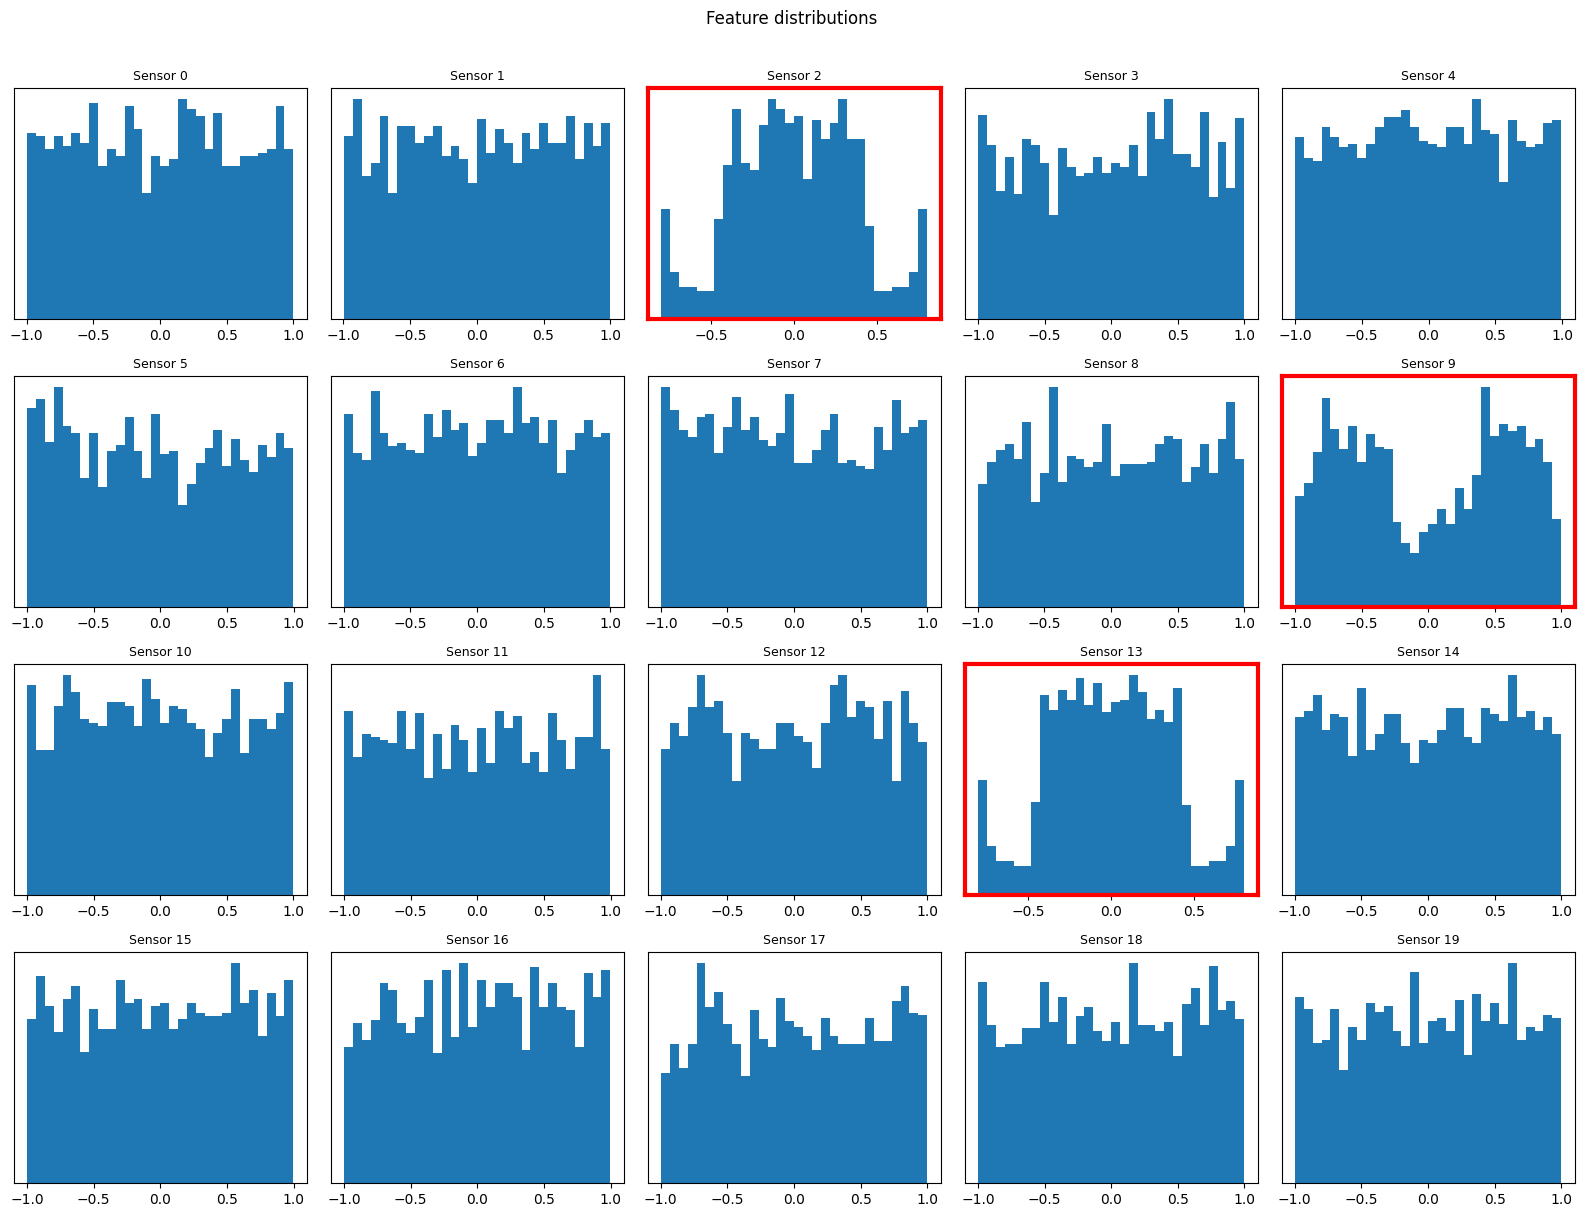

In [9]:
intersting_cols = ['Sensor 2', 'Sensor 9', 'Sensor 13']
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(data[col], bins=30, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
    if col in intersting_cols:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
plt.suptitle('Feature distributions', y=1.01)
plt.tight_layout()

Looking at these 3 columns has the added benefit that we can easily visualize.

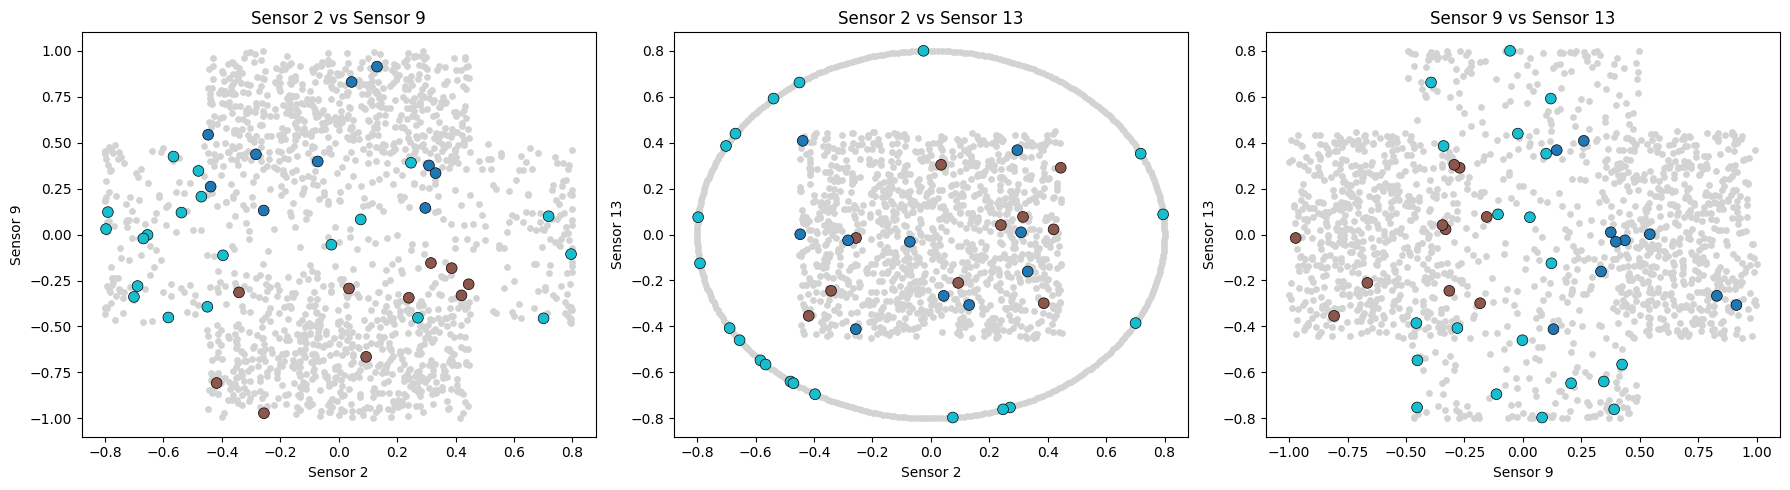

In [10]:
from itertools import combinations

sensor_cols = ['Sensor 2', 'Sensor 9', 'Sensor 13']
pairs = list(combinations(sensor_cols, 2))
labeled_mask = labels_known.notna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(data.loc[labels_known.isna(), x_col], data.loc[labels_known.isna(), y_col],
               c='lightgrey', s=15, label='unlabeled', zorder=1)
    ax.scatter(data.loc[labeled_mask, x_col], data.loc[labeled_mask, y_col],
               c=labels_known[labeled_mask].astype('category').cat.codes,
               cmap='tab10', s=60, zorder=2, edgecolors='black', linewidths=0.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
plt.tight_layout()

data["label"] = labels_known.fillna("unlabeled").astype(str)

fig3d = px.scatter_3d(
    data, x="Sensor 2", y="Sensor 13", z="Sensor 9",
    color="Label",
    color_discrete_map={"unlabeled": "lightgrey"},
    opacity=0.7,
    title="Interesting columns — labeled breakdowns on top of unlabeled"
)
fig3d.update_traces(marker_size=4)
fig3d.show()

This shows that the data follow a clear geometrical pattern that we should be able to uncover using clustering.

# Clustering

First, we naively try to cluster the data using k-means on just these columns to get a baseline.

**Note:** unlike a lot of other clustering problems we have a small set of labels that will help us determine whether we are on the right track. We will be using these to evaluate our clusters if it were a **classification**.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

X = data[['Sensor 2', 'Sensor 9', 'Sensor 13']].values
unique_labels = sorted(labels_known.dropna().unique())
k = len(unique_labels)
seed_centroids = np.array([X[labels_known == l].mean(axis=0) for l in unique_labels])

km = KMeans(n_clusters=k, init=seed_centroids, n_init=1, random_state=42)
km.fit(X)
data['km_label'] = data['cluster'] = km.labels_
data['km_label'] = data['km_label'].map(dict(enumerate(unique_labels)))

labeled_df = data[labels_known.notna()].copy()
print(classification_report(labeled_df['Label'].astype(int), labeled_df['km_label'].astype(int), zero_division=0))
plot_df = data[['Sensor 2', 'Sensor 9', 'Sensor 13', 'km_label']].copy()
plot_df['km_label'] = plot_df['km_label'].astype(str)
fig3d = px.scatter_3d(plot_df, x='Sensor 2', y='Sensor 9', z='Sensor 13',
    color='km_label', opacity=0.7, title='K-Means')
fig3d.update_traces(marker_size=4)
fig3d.show()


              precision    recall  f1-score   support

           1       0.78      0.70      0.74        10
           2       0.64      0.90      0.75        10
           3       0.76      0.65      0.70        20

    accuracy                           0.72        40
   macro avg       0.73      0.75      0.73        40
weighted avg       0.74      0.72      0.72        40



Then, we explore Gaussian Mixture Models, which relax the assumption of spherical clusters from K-Means and allow for more flexible cluster shapes.

In [12]:
from sklearn import mixture

gmm = mixture.GaussianMixture(n_components=k, covariance_type='full', means_init=seed_centroids, random_state=42)
gmm.fit(X)
data['gmm_label'] = gmm.predict(X)
data['gmm_label'] = data['gmm_label'].map(dict(enumerate(unique_labels)))

labeled_df = data[labels_known.notna()].copy()
print(classification_report(labeled_df['Label'].astype(int), labeled_df['gmm_label'].astype(int), zero_division=0))
plot_df = data[['Sensor 2', 'Sensor 9', 'Sensor 13', 'gmm_label']].copy()
plot_df['gmm_label'] = plot_df['gmm_label'].astype(str)
fig3d = px.scatter_3d(plot_df, x='Sensor 2', y='Sensor 9', z='Sensor 13',
    color='gmm_label', opacity=0.7, title='GMM')
fig3d.update_traces(marker_size=4)
fig3d.show()


              precision    recall  f1-score   support

           1       0.89      0.80      0.84        10
           2       0.69      0.90      0.78        10
           3       0.83      0.75      0.79        20

    accuracy                           0.80        40
   macro avg       0.80      0.82      0.80        40
weighted avg       0.81      0.80      0.80        40



# Feature engineering

Seeing as the data is so clearly seperable, we should be able to do better. But, most clustering algorithms work from some sort of "center" around which they acculumlate their clusters with some distance metric. 

**Idea**: transform the the features into a higher dimensional space keeping mind that
1. There is a clear interaction effect between Sensor 2 and 13
2. We need to look at the **radius** of the circle, as this is larger than the other points

_Pythagoras_ comes to mind.

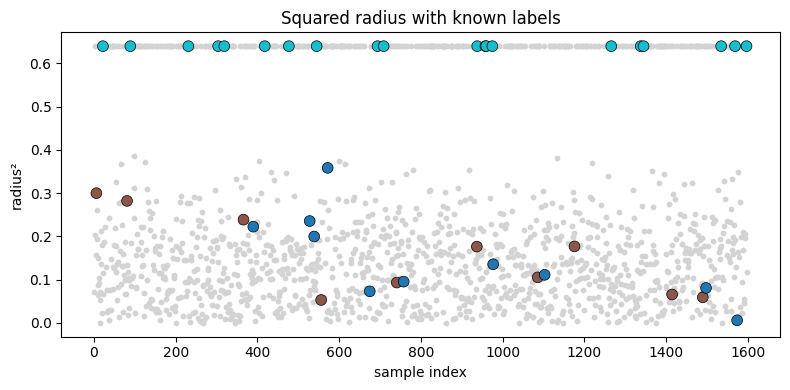

In [15]:
# Project into higher-dimensional space using squared radius
s2 = data['Sensor 2'].values
s13 = data['Sensor 13'].values
radius_sq = s2**2 + s13**2
data['radius_sq'] = radius_sq

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(len(data)), radius_sq, c='lightgrey', s=10, label='unlabeled', zorder=1)
labeled_mask = labels_known.notna()
ax.scatter(data.index[labeled_mask], radius_sq[labeled_mask],
           c=labels_known[labeled_mask].astype('category').cat.codes,
           cmap='tab10', s=60, zorder=2, edgecolors='black', linewidths=0.5)
ax.set_xlabel('sample index')
ax.set_ylabel('radius²')
ax.set_title('Squared radius with known labels')
plt.tight_layout()


# Stepwise Clustering

Then, we can devise a step-wise clustering algorithm:

- **Step 1:** 
    - a) Transform features such that surrounding sperical shape (label = 3) can be separated from the rest.
    - b) Cluster examples into outer / core.

- **Step 2:** Cluster the remaining core points using all 3 sensors.

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.50      1.00      0.67        10
           3       1.00      1.00      1.00        20

    accuracy                           0.75        40
   macro avg       0.50      0.67      0.56        40
weighted avg       0.62      0.75      0.67        40



/Users/wisse/dev/ml6/clustering_sensors/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/wisse/dev/ml6/clustering_sensors/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/wisse/dev/ml6/clustering_sensors/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

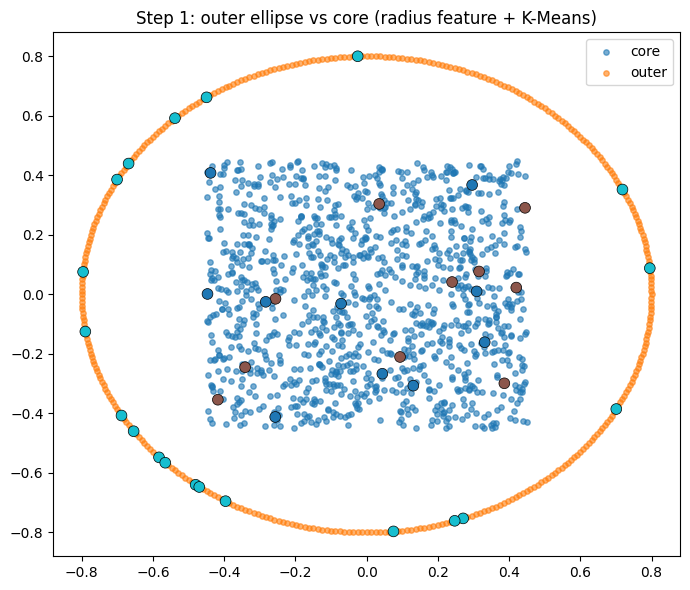

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report



km_step1 = KMeans(n_clusters=2, random_state=42, n_init=10)
data['step1_cluster'] = km_step1.fit_predict(np.column_stack([radius_sq]))

# Identify outer cluster by highest mean radius
mean_radius = data.groupby('step1_cluster')['radius_sq'].mean()
outer_cluster = mean_radius.idxmax()
data['step1_label'] = data['step1_cluster'].map({outer_cluster: 'outer', 1 - outer_cluster: 'core'})

fig, ax = plt.subplots(figsize=(7, 6))
for label, group in data.groupby('step1_label'):
    ax.scatter(group['Sensor 2'], group['Sensor 13'], s=15, label=label, alpha=0.6)
labeled_mask = labels_known.notna()
ax.scatter(data.loc[labeled_mask, 'Sensor 2'], data.loc[labeled_mask, 'Sensor 13'],
           c=labels_known[labeled_mask].astype('category').cat.codes,
           cmap='tab10', s=60, zorder=3, edgecolors='black', linewidths=0.5)
ax.set_title('Step 1: outer ellipse vs core (radius feature + K-Means)')
ax.legend()
plt.tight_layout()

# Map step1_label back to original labels: outer=3, core=majority label among labeled core points
labeled_df = data[labeled_mask].copy()
labeled_df['true_label'] = labels_known[labeled_mask].astype(int)
core_majority = labeled_df[labeled_df['step1_label'] == 'core']['true_label'].value_counts().idxmax()
pred_step1 = labeled_df['step1_label'].map({'outer': 3, 'core': core_majority})
print(classification_report(labeled_df['true_label'], pred_step1))

In [24]:
# Step 2: cluster core points into the 2 remaining classes
core_mask = data['step1_label'] == 'core'
X_core = data.loc[core_mask, ['Sensor 2', 'Sensor 9', 'Sensor 13']].values
labels_core = labels_known[core_mask]

core_labels = sorted(labels_core.dropna().unique())
k_core = len(core_labels)
seed_centroids_core = np.array([X_core[labels_core.values == l].mean(axis=0) for l in core_labels])

km_step2 = KMeans(n_clusters=k_core, init=seed_centroids_core, n_init=1, random_state=42)
cluster_ids = km_step2.fit_predict(X_core)

core_df = data.loc[core_mask].copy()
core_df['pred'] = cluster_ids
labeled_core = core_df[labels_core.notna()]
cluster_to_label = labeled_core.groupby('pred')['Label'].agg(lambda x: x.value_counts().idxmax())
core_df['pred_label'] = core_df['pred'].map(cluster_to_label).fillna(-1).astype(str)

fig3d = px.scatter_3d(core_df, x='Sensor 2', y='Sensor 9', z='Sensor 13',
    color='pred_label', opacity=0.7, title='Step 2: K-Means')
fig3d.update_traces(marker_size=4)
fig3d.show()

valid = labeled_core[labeled_core['pred'].isin(cluster_to_label.index)]
print(classification_report(valid['Label'].astype(int), valid['pred'].map(cluster_to_label).astype(int), zero_division=0))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [18]:
# Join step 1 (outer=3) and step 2 (core labels 1 & 2) predictions
data['final_label'] = None
data.loc[data['step1_label'] == 'outer', 'final_label'] = 3
data.loc[core_df.index, 'final_label'] = core_df['pred_label']

labeled_df = data[labels_known.notna()].copy()
print("=== Final stepwise classification report ===")
print(classification_report(
    labeled_df['Label'].astype(int),
    labeled_df['final_label'].astype(float).astype(int)
))

=== Final stepwise classification report ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



As a sanity check, we also try to apply KMeans directly on the transformed features. But, this still deals with the fact that the clusters are not captured in single spheres.

In [20]:
# All-in-one: K-Means on Sensor 2, 9, 13 + radius² feature
s2 = data['Sensor 2'].values
s13 = data['Sensor 13'].values
radius_sq = s2**2 + s13**2
X_full = np.column_stack([data[['Sensor 2', 'Sensor 9', 'Sensor 13']].values, radius_sq])

unique_labels = sorted(labels_known.dropna().unique())
seed_centroids_full = np.array([X_full[labels_known == l].mean(axis=0) for l in unique_labels])

km_full = KMeans(n_clusters=3, init=seed_centroids_full, n_init=1, random_state=42)
data['km_full_label'] = km_full.fit_predict(X_full)
data['km_full_label'] = data['km_full_label'].map(dict(enumerate(unique_labels)))

labeled_df = data[labels_known.notna()].copy()
print(classification_report(labeled_df['Label'].astype(int), labeled_df['km_full_label'].astype(int), zero_division=0))

plot_df = data[['Sensor 2', 'Sensor 9', 'Sensor 13', 'km_full_label']].copy()
plot_df['km_full_label'] = plot_df['km_full_label'].astype(str)
fig3d = px.scatter_3d(plot_df, x='Sensor 2', y='Sensor 9', z='Sensor 13',
    color='km_full_label', opacity=0.7, title='K-Means with radius² feature (all-in-one)')
fig3d.update_traces(marker_size=4)
fig3d.show()


              precision    recall  f1-score   support

           1       0.80      0.80      0.80        10
           2       0.71      1.00      0.83        10
           3       0.88      0.70      0.78        20

    accuracy                           0.80        40
   macro avg       0.80      0.83      0.80        40
weighted avg       0.82      0.80      0.80        40



# Results

- We are able to cluster all data points provided, which are geometrically sensible.
- We are able to verify that the clustering is sensible based on 40 labelled data, that we are able to classify 100% correctly.
- We are now able to identify what type of breakdowns are most prevalent so Customer A can direct attention to resolving these first.

| Approach | Precision | Recall | F1 |
|---|---|---|---|
| K-Means (3 sensors) | 0.74 | 0.72 | 0.72 |
| GMM (3 sensors) | 0.81 | 0.80 | 0.80 |
| K-Means + radius² | 0.82 | 0.80 | 0.80 |
| **Stepwise** | **1.00** | **1.00** | **1.00** |

We can now investigate what the most frequent breakdown cause is.

Text(0, 0.5, 'Count')

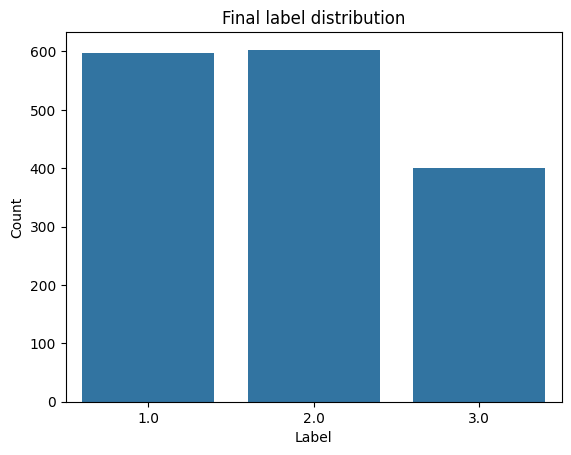

In [21]:
sns.barplot(data['final_label'].astype(float).value_counts())
plt.title('Final label distribution')
plt.xlabel('Label')
plt.ylabel('Count')

# Conclusion

For this problem, it seems that a simple 2-step KMeans clustering with some feature engineering gives us the best results on the labeled data. If we can assume this to be a good representation of the unlabeled data, we can use this approach as a classifier directly.

In the short term, Customer A should be focussing on resolving errors based on type 1 and 2 before type 3, as those are most prevalent.

## Next steps

If we want to build this out to a live outage classifier system I would suggest the following approach:

1. **Label more data** to see how well this classifier extrapolates as we only evaluate on training data now. This would allow us to evaluate the labelling of currently unlabeled data.

2. Explore possibility of training a normal **non-linear classifier** on the full set of labelled data as it's a more robust approach.

3. **Deploy model** such that new breakdowns can be classified in **real-time**.